## Rank miRNAs
This notebook `02_rank_mirnas.ipynb` does hit calling, i.e. ranks miRNAs by the
effect they had on cellular morphology.
It will demonstrate how to rank miRNAs using HEK293T as an example,
to analyse results of another cell line just change the path of the `adata_file`.

Before getting started with this notebook, make sure you have followed the setup
instructions in the [README.md](README.md).

Note: to make this notebook easier to run on devices without large RAM, you may
enable AnnData's `backed` mode to load in data only when required. This does make
processing slower. If you wish to use this mode, change `save_memory` to `True`
in the first code cell.


For a simpler sample notebook on how to do hit calling with scmorph, see: https://scmorph.readthedocs.io/en/latest/tutorials/basics/hit_calling.html.

In [ ]:
# check that an input file exists
import os

save_memory = False

# change to the file you wish to use in the analysis, here using HEK293T
adata_file = "workspace/profiles_assembled/profiles_processed/HEK293T_features_processed.h5ad"

assert os.path.exists(adata_file), f"anndata file {adata_file} not found."

In [2]:
# load dependencies
import pandas as pd
import numpy as np
import scmorph as sm
from tqdm import tqdm
from plotnine import *
import matplotlib.pyplot as plt
from natsort import natsorted

In [3]:
# Set plotting parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9

In [4]:
adata = sm.read(adata_file, backed="r" if save_memory else None)
adatas_per_plate = {}
for plate in adata.obs["PlateID"].unique():
    adata_ss = adata[adata.obs["PlateID"] == plate]
    adatas_per_plate[plate] = adata_ss

# Perform hit calling

In [5]:
# Define control wells present across all plates
ctrl_wells = ['E23', 'E24', 'F23', 'F24', 'I23', 'I24', 'J23', 'J24']

In [6]:
# Test treatments' significance per plate
ref_ks_d = {}
treat_ks_d = {}
for plate in tqdm(adatas_per_plate):
    ref_ks_d[plate] = {}
    treat_ks_d[plate] = {}
    adata_ss = adatas_per_plate[plate]
    if adata_ss.isbacked:
        adata_ss = adata_ss.to_memory()
    ref_ks_d[plate], treat_ks_d[plate] = sm.tl.get_ks(adata_ss,
                                                        treatment_key="treatment",
                                                        control_wells=ctrl_wells,
                                                        progress=False,
                                                        n_pcs=10,
                                                        scale_by_var=True)

100%|██████████| 30/30 [00:48<00:00,  1.63s/it]


In [7]:
# Add metadata to resulting dataframes
for plate in ref_ks_d:
    plate_layout = adatas_per_plate[plate].obs["PlateLayout"].values[0]
    rep = adatas_per_plate[plate].obs["Replicate"].values[0]
    ref_ks_d[plate].insert(0, "PlateLayout", plate_layout)
    ref_ks_d[plate].insert(0, "Replicate", rep)
    treat_ks_d[plate].insert(0, "PlateLayout", plate_layout)
    treat_ks_d[plate].insert(0, "Replicate", rep)

In [8]:
# Collect dataframes across all plates
ref_ks = pd.concat([ref_ks_d[rep] for rep in ref_ks_d]).dropna()
treat_ks = pd.concat([treat_ks_d[rep] for rep in treat_ks_d]).dropna()

In [9]:
# Add text representations of significance
sig_mapping = {0: "NS", 1: "10%", 2: "5%"}

treat_ks["significance"] = (treat_ks["is_significant_0.05"].astype(int) + treat_ks["is_significant_0.1"]).map(sig_mapping)
treat_ks["significance"] = treat_ks["significance"].astype("category").cat.set_categories(["NS", "10%", "5%"], ordered=True)
treat_ks["plate"] = treat_ks["PlateLayout"].str[1:].astype(int).astype("category")

ref_ks["significance"] = (ref_ks["is_significant_0.05"].astype(int) + ref_ks["is_significant_0.1"]).map(sig_mapping)
ref_ks["significance"] = ref_ks["significance"].astype("category").cat.set_categories(["NS", "10%", "5%"], ordered=True)
ref_ks["plate"] = ref_ks["PlateLayout"].str[1:].astype(int).astype("category")

The output dataframe has the following column structure:

1. Biological replicate number (`Replicate`)
2. Plate map number (`PlateLayout`)
3. Control that treatment was compared to (`control`)
4. `treatment` is the name of the treatment that is being compared to `control`

Moving to the results, we have:

5. The KS statistic of the significance test (`ks_stat`)
6. The empirical p-value of the KS statistic (`ks_pval`)
7. The FDR-correct p-value of the KS statistic (`ks_qval`)

And the resulting interpretations:

8. `is_significant_0.05` shows whether the treatment was significant at an alpha
   of 5%
9. Similarly, `is_significant_0.1` does the same at the 10% cutoff
10. The column `significance` is one of `NS` (not significant), `NT` (not
    tested)`, and `5%`/`10%` (significant at 5% or 10% threshold).

The last column, `plate`, is simply used in further processing if needed.

The whole dataframe can be viewed like this:

In [10]:
treat_ks

,Replicate,PlateLayout,control,treatment,ks_stat,ks_pval,ks_qval,is_significant_0.05,is_significant_0.1,significance,plate
0,1,P1,control_neg_mimic,DMSO,0.042648,4.425892e-02,1.625838e-01,False,False,NS,1
1,1,P1,control_neg_mimic,control_cell_death,0.370704,4.061204e-100,7.310168e-98,True,True,5%,1
2,1,P1,control_neg_mimic,control_tr_rotenone,0.221333,2.879841e-30,2.591857e-28,True,True,5%,1
3,1,P1,control_neg_mimic,control_transfection_reagent_only,0.042237,4.174662e-03,2.277088e-02,True,True,5%,1
4,1,P1,control_neg_mimic,hsa-let-7a-5p,0.025713,4.687655e-01,6.916212e-01,False,False,NS,1
...,...,...,...,...,...,...,...,...,...,...,...
101,2,P15,control_neg_mimic,hsa-miR-8069,0.080341,3.225806e-04,1.709677e-03,True,True,5%,15
102,2,P15,control_neg_mimic,hsa-miR-8072,0.069002,1.373655e-03,5.392867e-03,True,True,5%,15
103,2,P15,control_neg_mimic,hsa-miR-8073,0.025524,3.864722e-01,4.819536e-01,False,False,NS,15
104,2,P15,control_neg_mimic,hsa-miR-8078,0.023277,4.909974e-01,5.847834e-01,False,False,NS,15


We can see results for individual treatments using:

In [11]:
treat_ks.loc[treat_ks["treatment"] == "hsa-miR-9-5p"]

,Replicate,PlateLayout,control,treatment,ks_stat,ks_pval,ks_qval,is_significant_0.05,is_significant_0.1,significance,plate
7,1,P2,control_neg_mimic,hsa-miR-9-5p,0.100278,0.000055,0.000360,True,True,5%,2
7,2,P2,control_neg_mimic,hsa-miR-9-5p,0.099155,0.000049,0.001474,True,True,5%,2


Which shows that, in HEK293T, hsa-miR-9-5p led to a significant change in
morphology in both biological replicates.

## Ranking miRNAs

In [12]:
treat_no_ctrl_ks = treat_ks.loc[~treat_ks["treatment"].str.startswith("control")]
treat_no_ctrl_ks = treat_no_ctrl_ks.loc[~(treat_no_ctrl_ks["treatment"].isin(["DMSO","empty"]))]
treat_no_ctrl_ks["mirna-base"] = treat_no_ctrl_ks["treatment"].str.split("-").str[1:].str.join("-")
treat_no_ctrl_ks

,Replicate,PlateLayout,control,treatment,ks_stat,ks_pval,ks_qval,is_significant_0.05,is_significant_0.1,significance,plate,mirna-base
4,1,P1,control_neg_mimic,hsa-let-7a-5p,0.025713,4.687655e-01,6.916212e-01,False,False,NS,1,let-7a-5p
5,1,P1,control_neg_mimic,hsa-miR-7-1-3p,0.007171,9.344504e-01,9.675561e-01,False,False,NS,1,miR-7-1-3p
6,1,P1,control_neg_mimic,hsa-miR-7-5p,0.031777,3.083380e-01,5.606146e-01,False,False,NS,1,miR-7-5p
7,1,P1,control_neg_mimic,hsa-miR-18b-5p,0.055281,3.891441e-02,1.502278e-01,False,False,NS,1,miR-18b-5p
8,1,P1,control_neg_mimic,hsa-miR-19a-5p,0.126272,3.963817e-09,1.189145e-07,True,True,5%,1,miR-19a-5p
...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,P15,control_neg_mimic,hsa-miR-8069,0.080341,3.225806e-04,1.709677e-03,True,True,5%,15,miR-8069
102,2,P15,control_neg_mimic,hsa-miR-8072,0.069002,1.373655e-03,5.392867e-03,True,True,5%,15,miR-8072
103,2,P15,control_neg_mimic,hsa-miR-8073,0.025524,3.864722e-01,4.819536e-01,False,False,NS,15,miR-8073
104,2,P15,control_neg_mimic,hsa-miR-8078,0.023277,4.909974e-01,5.847834e-01,False,False,NS,15,miR-8078


We can see miRNAs ranked by the mean KS statistic (across both bio
replicates) using this:

In [13]:
mirna_ks_res = (
    treat_no_ctrl_ks
    .groupby("mirna-base")
    .apply(lambda x: x["ks_stat"].mean(), include_groups=False)
    .sort_values(ascending=False)
)
mirna_ks_res.head(10)

mirna-base
miR-3140-3p    0.246040
miR-221-5p     0.245051
miR-9-3p       0.216935
miR-518b       0.186963
miR-5681a      0.178946
miR-182-5p     0.177347
miR-518d-3p    0.173480
miR-5191       0.168053
miR-708-5p     0.167278
miR-613        0.165652
dtype: float64

We can use this ranking to go back to the per-replicate data and sort the
dataframe by the mirnas' mean KS statistic:

In [14]:
treat_no_ctrl_ks["mirna-base"] = treat_no_ctrl_ks["mirna-base"].astype("category").cat.reorder_categories(mirna_ks_res.index)
treat_no_ctrl_ks.sort_values("mirna-base", inplace=True)
treat_no_ctrl_ks.head(10)

,Replicate,PlateLayout,control,treatment,ks_stat,ks_pval,ks_qval,is_significant_0.05,is_significant_0.1,significance,plate,mirna-base
36,2,P3,control_neg_mimic,hsa-miR-3140-3p,0.189052,3.596216e-18,2.157730e-16,True,True,5%,3,miR-3140-3p
36,1,P3,control_neg_mimic,hsa-miR-3140-3p,0.303028,2.907362e-34,2.616626e-32,True,True,5%,3,miR-3140-3p
55,1,P11,control_neg_mimic,hsa-miR-221-5p,0.400381,2.407115e-06,2.888538e-05,True,True,5%,11,miR-221-5p
55,2,P11,control_neg_mimic,hsa-miR-221-5p,0.089721,2.457224e-04,4.423004e-03,True,True,5%,11,miR-221-5p
6,2,P14,control_neg_mimic,hsa-miR-9-3p,0.232121,9.105656e-19,1.639018e-16,True,True,5%,14,miR-9-3p
6,1,P14,control_neg_mimic,hsa-miR-9-3p,0.201749,1.571616e-20,2.828909e-18,True,True,5%,14,miR-9-3p
93,1,P11,control_neg_mimic,hsa-miR-518b,0.258085,6.909853e-21,4.145912e-19,True,True,5%,11,miR-518b
93,2,P11,control_neg_mimic,hsa-miR-518b,0.115842,5.272981e-08,2.372841e-06,True,True,5%,11,miR-518b
173,2,P7,control_neg_mimic,hsa-miR-5681a,0.160268,1.868470e-12,1.121082e-10,True,True,5%,7,miR-5681a
172,1,P7,control_neg_mimic,hsa-miR-5681a,0.197624,4.163840e-16,1.863318e-14,True,True,5%,7,miR-5681a


As you can see, some miRNAs have considerably varied responses. For example
hsa-miR-221-5p has a KS statistic of 0.400381 in replicate 1 and 0.089721 in
replicate 2, respectively. On the other hand hsa-miR-9-3p scores at 0.201749 and
0.232121 in R1 and R2 and thus represents a more consistent result.

## Control variability

To observe the variability of the morphological response to a positive control
treatment with cell death inducing siRNAs, we can use the following.

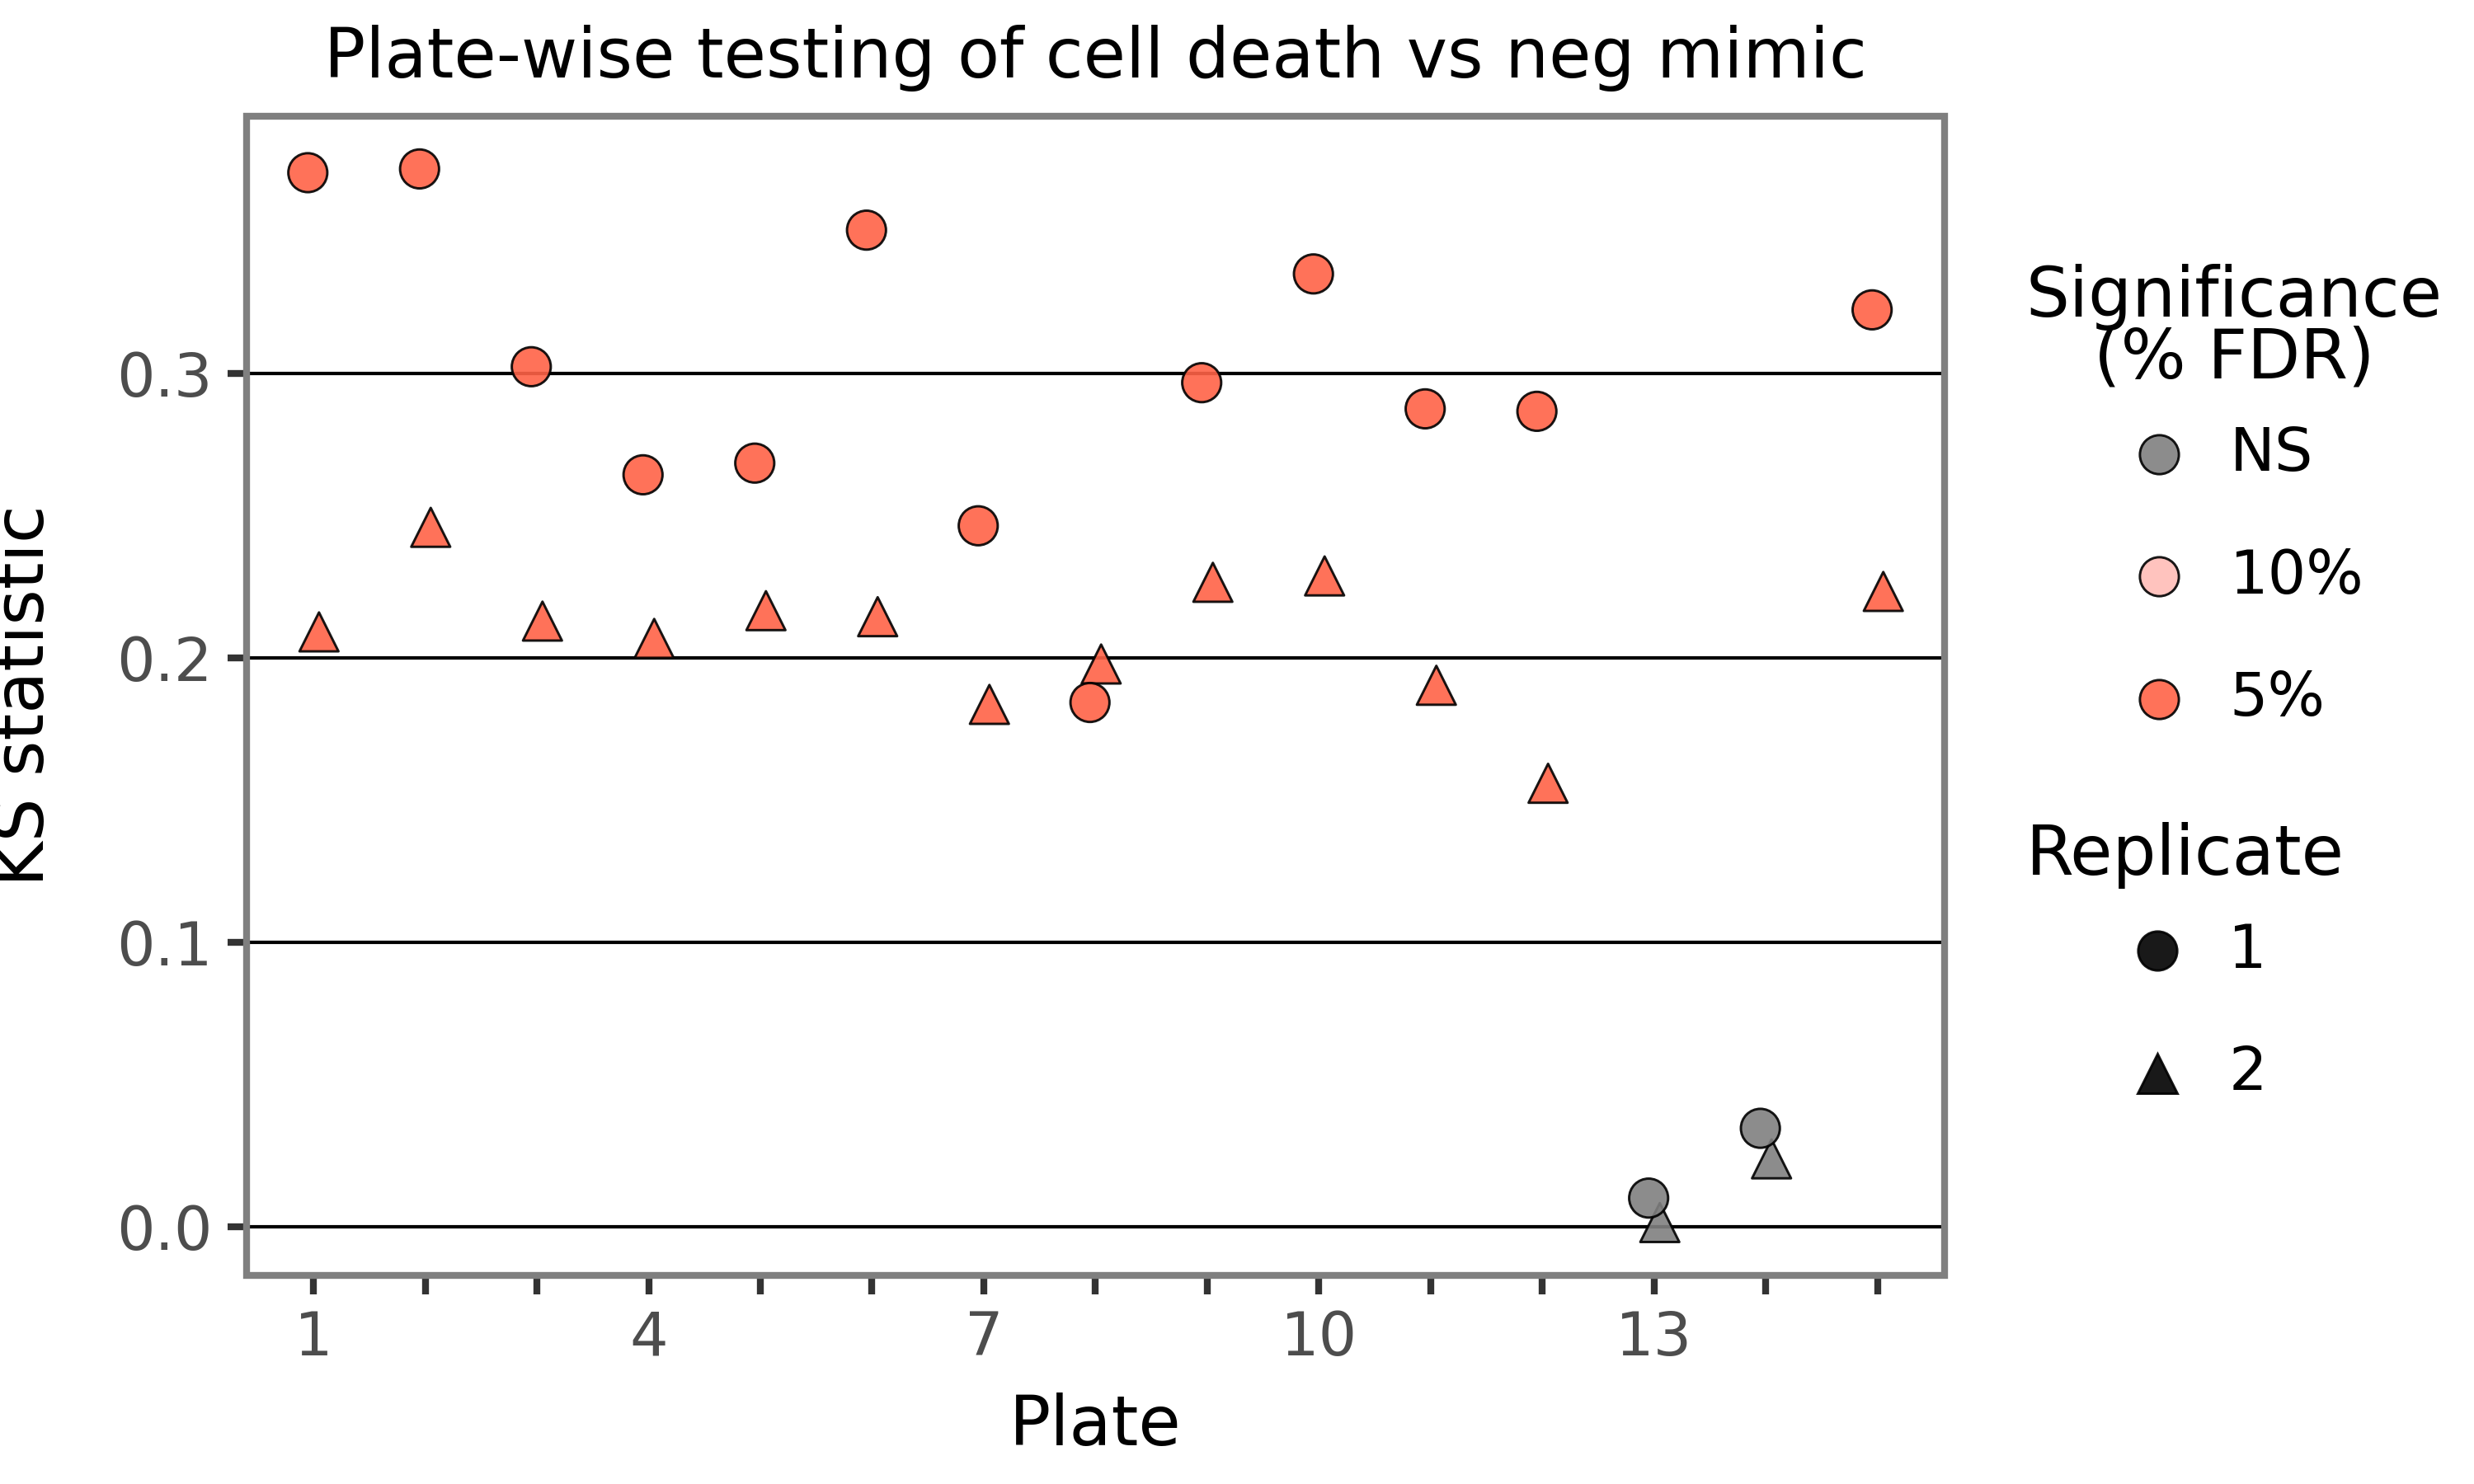

In [15]:
pos_control_ks = treat_ks.query("treatment == 'control_cell_death'").copy()
pos_control_ks["Replicate"] = pos_control_ks["Replicate"].astype("category")

def x_labeler(x):
    x_labels = natsorted(np.unique(x))
    x_labels = [l if i % 3 == 0 else "" for i, l in enumerate(x_labels)]
    return x_labels

(
    ggplot(pos_control_ks, aes(x="plate",y="ks_stat", fill="significance", shape="Replicate")) +
    geom_point(position=position_dodge(width=0.2), color="black", stroke=0.2, size=3, alpha=0.9) +
    theme_bw() +
    labs(x="Plate",y="KS statistic", fill="Significance\n(% FDR)", shape="Replicate") +
    ggtitle("Plate-wise testing of cell death vs neg mimic") +
    scale_x_discrete(labels = lambda x: x_labeler(x)) +
    scale_fill_manual(values=["gray", "#FFBDB7", "#FF6347"]) +
    theme(figure_size=(5, 3),
          dpi=300,
          title=element_text(size=10, hjust=0.5),
          panel_grid_major_x=element_blank(),
          panel_grid_minor_x=element_blank(),
          panel_grid_major_y=element_line(size=0.5, color="black"),
          panel_grid_minor_y=element_blank(),
          strip_background=element_blank(),
          legend_key=element_blank(),
          )
)

Similarly, we can see that rotenone had a pronounced effect in HEK293T:

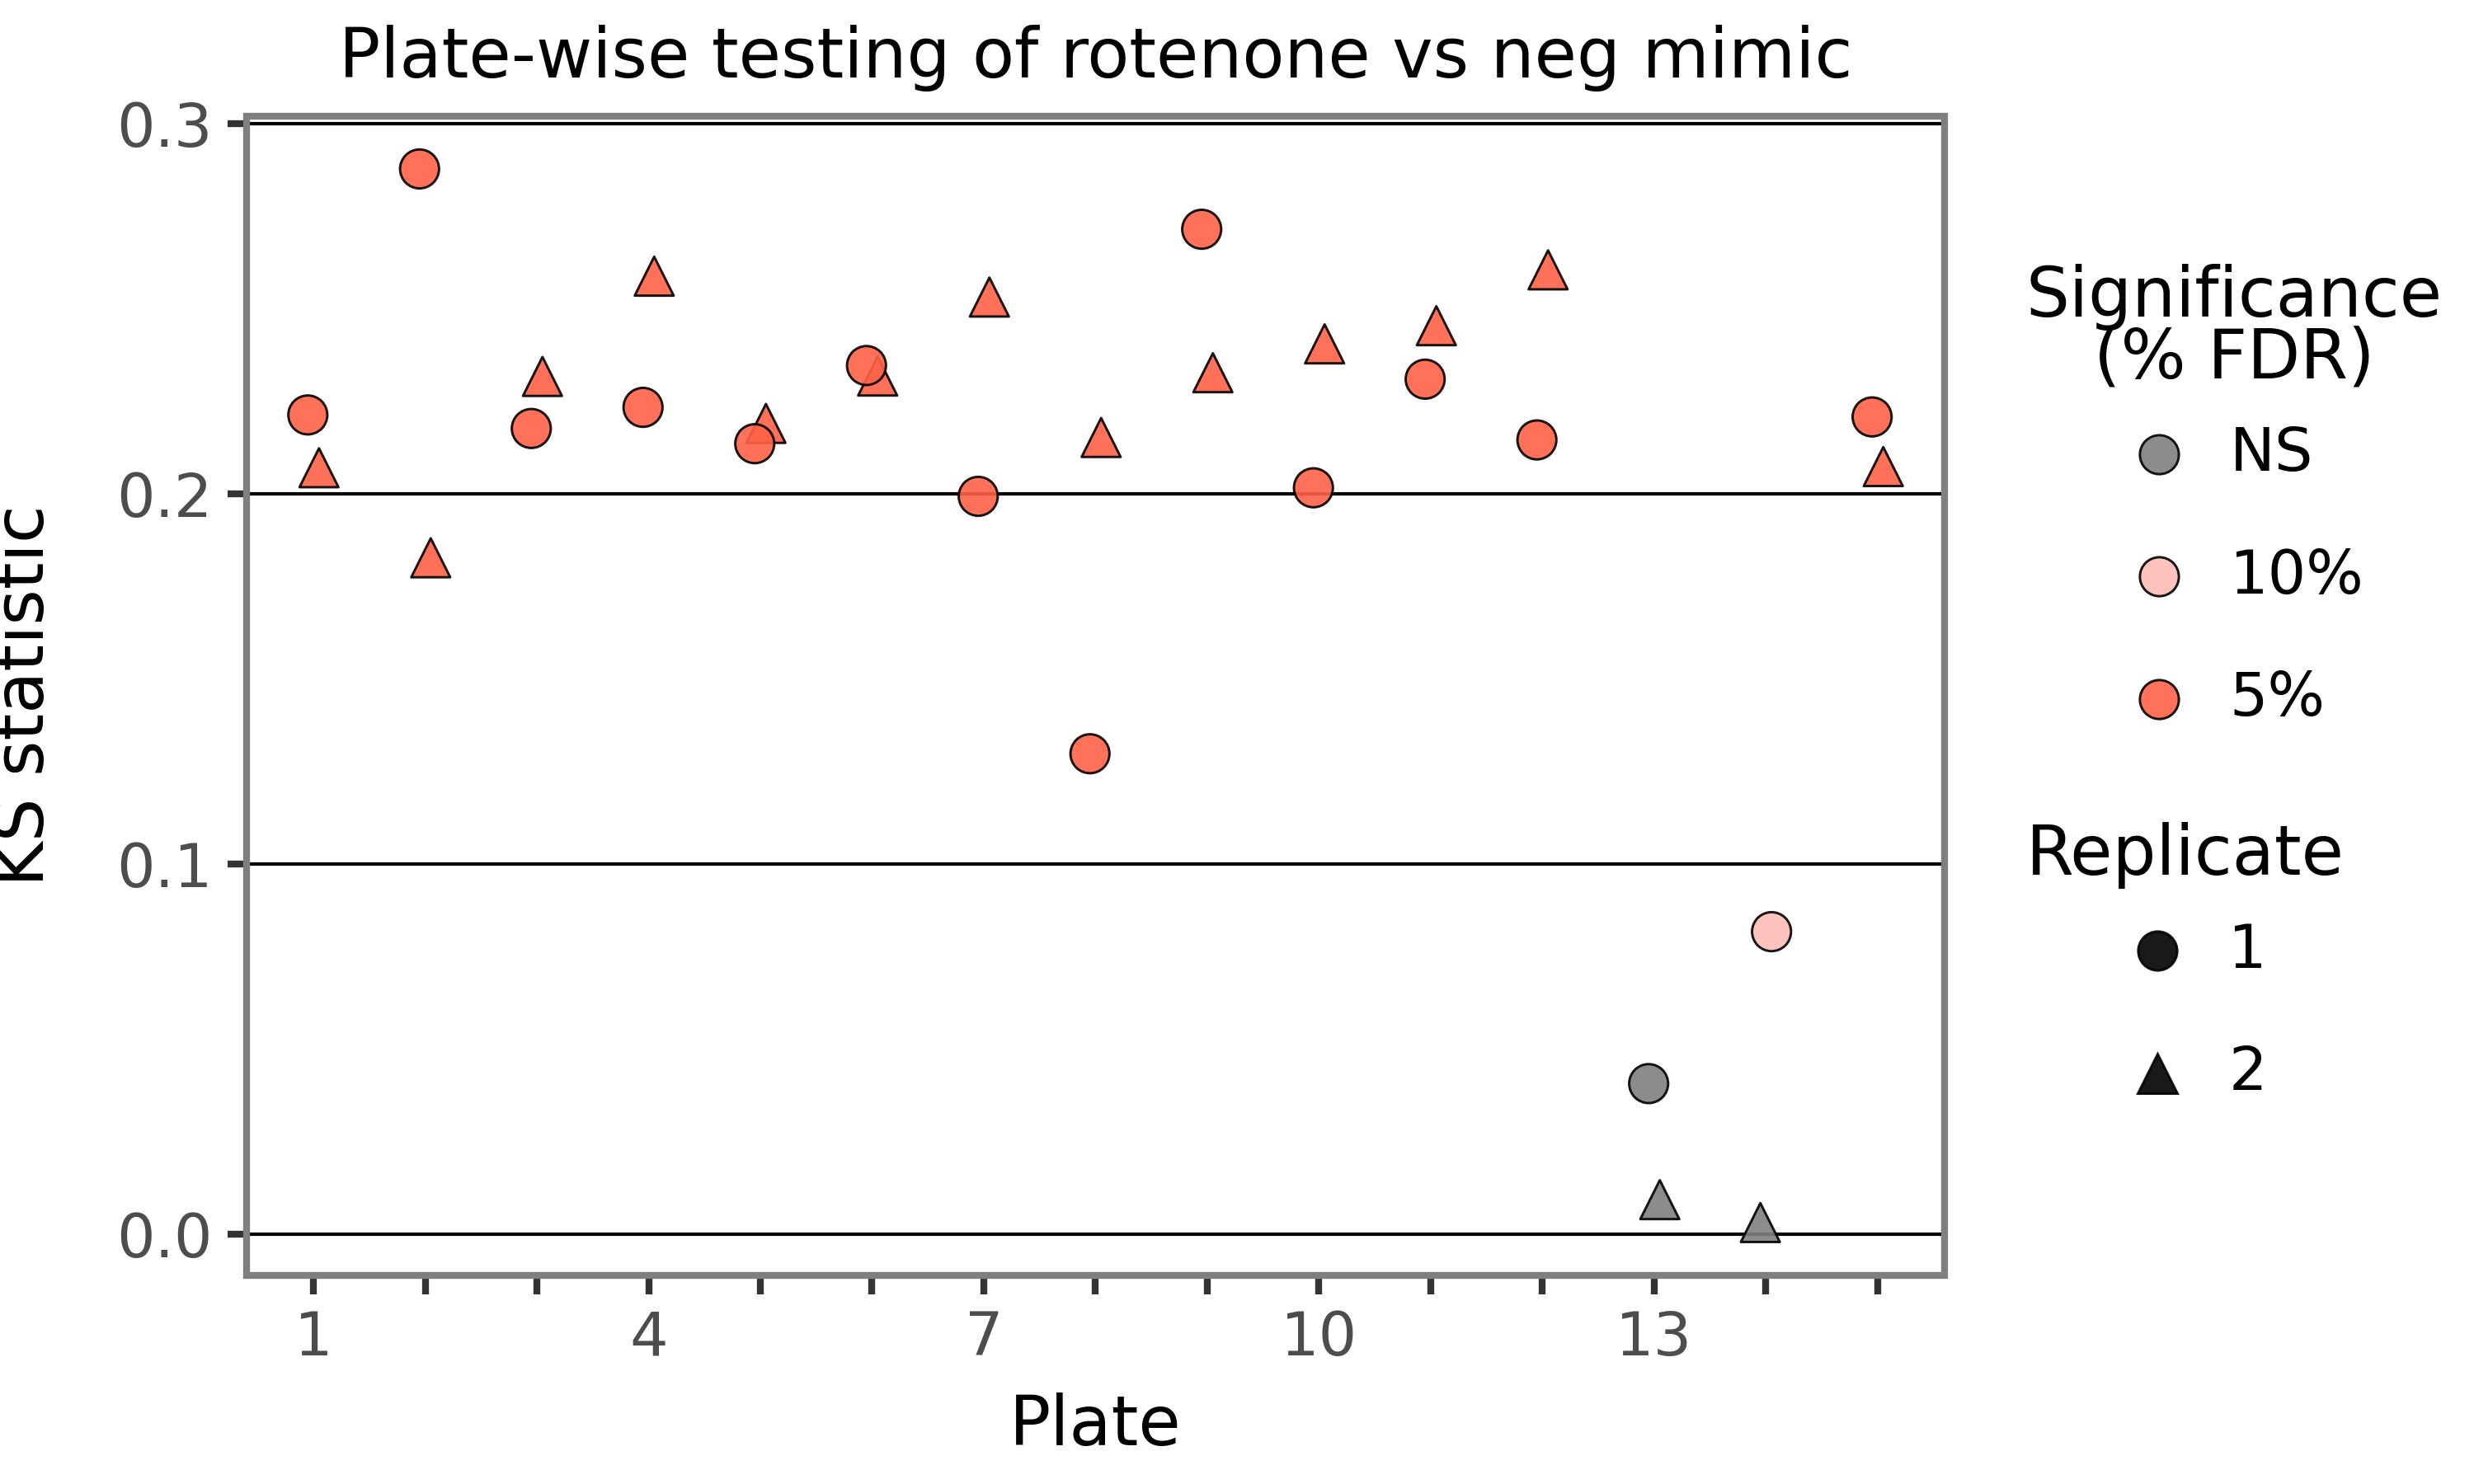

In [16]:
rotenone_ks = treat_ks.query("treatment == 'control_tr_rotenone'").copy()
rotenone_ks["Replicate"] = rotenone_ks["Replicate"].astype("category")

(
    ggplot(rotenone_ks, aes(x="plate",y="ks_stat", fill="significance", shape="Replicate")) +
    geom_point(position=position_dodge(width=0.2), color="black", stroke=0.2, size=3, alpha=0.9) +
    theme_bw() +
    labs(x="Plate",y="KS statistic", fill="Significance\n(% FDR)", shape="Replicate") +
    ggtitle("Plate-wise testing of rotenone vs neg mimic") +
    scale_x_discrete(labels = lambda x: x_labeler(x)) +
    scale_fill_manual(values=["gray", "#FFBDB7", "#FF6347"]) +
    theme(figure_size=(5, 3),
          dpi=300,
          title=element_text(size=10, hjust=0.5),
          panel_grid_major_x=element_blank(),
          panel_grid_minor_x=element_blank(),
          panel_grid_major_y=element_line(size=0.5, color="black"),
          panel_grid_minor_y=element_blank(),
          strip_background=element_blank(),
          legend_key=element_blank(),
          )
)